## Calculate rainfall exceedance thresholds for Storm Desmond from ERA5

In [1]:
import os
import itertools
import logging

import math
from datetime import timedelta, datetime

import numpy as np
import xarray as xr
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

import matplotlib as mpl
from matplotlib.colors import ListedColormap, BoundaryNorm, Normalize
try:
    # MetPy import (works for different MetPy versions)
    from metpy.plots import ctables
except Exception as exc:
    raise ImportError("MetPy is required to use MetPy color tables") from exc

import metpy.plots.ctables as mp
sns.set_theme()

/home/jbanorthwest.co.uk/samhardy/miniforge3/envs/earth2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Read in the ERA5 data and aggregate to 24-h accumulations

In [20]:
def normalise_longitude(ds: xr.Dataset, 
                        lon_name='lon'):
    """ 
    Convert longitude from [0...360] to [-180...180] if necessary and sort the dataset by longitude.
    This ensures that the longitude coordinates are in a consistent format for plotting and analysis, 
    especially when working with global datasets that may use different longitude conventions. 
    """
    lon = ds[lon_name]
    if float(lon.max()) > 180:
        # map 0..360 -> -180..180 and re-sort
        ds = ds.assign_coords({lon_name: ((lon + 180) % 360) - 180}).sortby(lon_name)
    return ds


def select_subset_by_bbox(ds: xr.Dataset, 
                          bbox=[-12.0, 2.5, 48.0, 60.0]):
    """ 
    Select a subset of the dataset based on a bounding box (lon0, lon1, lat0, lat1). This is useful for focusing on a specific region (e.g. UK and Ireland) and speeding up processing and plotting.
    """
    # Determine latitude and longitude coord names
    if 'latitude' in ds.coords:
        lat_name = 'latitude'
    elif 'lat' in ds.coords:
        lat_name = 'lat'
    else:
        raise ValueError("No latitude coordinate found (expected 'lat' or 'latitude').")

    if 'longitude' in ds.coords:
        lon_name = 'longitude'
    elif 'lon' in ds.coords:
        lon_name = 'lon'
    else:
        raise ValueError("No longitude coordinate found (expected 'lon' or 'longitude').")

    # Ensure latitudes are ordered from south -> north (ascending)
    ds = ds.sortby(lat_name)

    # latitude and longitude bounds for UK and Ireland region (lon0, lon1, lat0, lat1)
    lon0, lon1, lat0, lat1 = bbox
    ds = ds.sel({lat_name:slice(lat0,lat1), lon_name:slice(lon0,lon1)})

    return ds, lat_name, lon_name


def preprocess_era5_rainfall(ds: xr.Dataset,
                             rolling_window: int,
                             min_periods: int,
                             event_end_date = '2015-12-06T00',
                             bbox = [-12.0, 2.5, 48.0, 60.0],
                             lead_dim = 'valid_time') -> xr.DataArray:
    """ 
    Pre-process ERA5 rainfall data to be in the correct format for calculating threshold exceedance. This includes:
        - converting units from m to mm
    """

    # check for singleton time dimensions and squeeze 
    # singleton_dims = [dim for dim, size in ds.sizes.items() if size == 1] 
    singleton_dims = [] 
    for dim, size in ds.sizes.items():
        if size == 1:
            singleton_dims.append(dim)
    if 'time' in singleton_dims:
        ds = ds.squeeze(dim='time')

    # select subset of data for UK and Ireland region to speed up processing and plotting
    ds, _, lon_name = select_subset_by_bbox(ds, bbox=bbox)

    # normalise longitude if required (e.g. if dataset uses 0..360 but we want -180..180 for plotting)
    ds = normalise_longitude(ds, lon_name=lon_name)

    # change units of precip from 'm' to 'mm'
    # TODO: generalise for different variable names and units, e.g. by passing in the variable name and expected input and output units as parameters
    da_pr = ds['tp'] * 1000.0

    if rolling_window is not None:
        if lead_dim is None:
            raise ValueError("Cannot compute rolling window without a lead/time dimension.")
        # rolling produces same-length lead dimension with NaNs in first (rolling_window-1) positions
        da_pr_roll = da_pr.rolling({lead_dim: rolling_window}, min_periods=min_periods).sum()
    else:
        # assume da_s already is 24h totals with a lead_dim
        da_pr_roll = da_pr

    # select date and accumulation period (e.g. 24-h, 48-h)
    da_pr_roll = da_pr_roll.sel(valid_time=(event_end_date))

    # assign relevant metadata as attributes for later use
    da_pr_roll.attrs['accumulation_period'] = rolling_window
    da_pr_roll.attrs['event_end_date'] = event_end_date

    return da_pr_roll


def get_metpy_colourmap(name='precipitation'):
    """
    Return a matplotlib Colormap object for a MetPy colortable name.
    Handles several MetPy API return formats.
    """
    cmap_src = None
    # try possible APIs
    if hasattr(ctables, 'get_colortable'):
        cmap_src = ctables.get_colortable(name)        # newer API sometimes returns colormap or list
    elif isinstance(ctables, dict) and name in ctables:
        cmap_src = ctables[name]                       # older API returns list or tuple
    else:
        # try other attributes (some versions expose colortables dict)
        try:
            cmap_src = ctables.colortables[name]
        except Exception:
            raise KeyError(f"Could not find MetPy colortable '{name}' in this MetPy version")

    # If MetPy already returned a Colormap, use it
    if isinstance(cmap_src, mpl.colors.Colormap):
        return cmap_src

    # If it returned a tuple like (colors, bounds), extract colors
    if isinstance(cmap_src, tuple) and len(cmap_src) >= 1:
        colors = cmap_src[0]
    else:
        colors = cmap_src

    # Convert colors to numpy array
    colors = np.asarray(colors)

    # If colors are Nx3 or Nx4 integer 0..255, scale to 0..1
    if np.issubdtype(colors.dtype, np.integer):
        if colors.max() > 1:
            colors = colors.astype(float) / 255.0

    # If colors are Nx3 or Nx4 floats already 0..1, accept
    # If colors are hex strings, ListedColormap can handle them directly

    # Finally create a ListedColormap
    try:
        cmap = ListedColormap(colors, name=name)
    except Exception:
        # Fallback: try converting each color to an mpl color string
        cmap = ListedColormap([mpl.colors.to_rgba(c) for c in colors], name=name)

    # set NaN colour to light gray, and out-of-range colours to white (under) and black (over)
    cmap.set_bad('lightgray')   # NaNs
    cmap.set_under('white')     # < vmin
    cmap.set_over('black')      # > vmax

    return cmap


def format_accumulation_str(acc_period):
    """
    Format the accumulation period (e.g. 24) into a string for the title (e.g. '24-h').
    """
    if acc_period is None:
        return None
    # handle numeric values (int, float, numpy numeric types)
    if isinstance(acc_period, (int, float, np.integer, np.floating)):
        return f"{int(acc_period)}-h"
    # convert strings like '48h' or '48 h' to '48-h'
    s = str(acc_period).strip()
    # if s is numeric (e.g. '48'), append '-h'
    if s.isdigit():
        return f"{int(s)}-h"
    return s


def formatted_uk_and_ireland_plot(ds: xr.DataArray | xr.Dataset,
                                  bbox=[-12, 2.5, 48.0, 60.0],
                                  cmap=get_metpy_colourmap('precipitation')):  
    """ 
    Create a formatted contour plot for the UK and Ireland region, using Cartopy for mapping and MetPy color tables for styling.
    """
    crs = ccrs.PlateCarree()
    cmap = cmap if cmap is not None else get_metpy_colourmap('precipitation')

    # ensure cmap is a Colormap instance (or get base cmap by name)
    if isinstance(cmap, str):
        base_cmap = plt.get_cmap(cmap)
    else:
        base_cmap = cmap

    # accept dataset with variable of interest, or DataArray directly
    if isinstance(ds, xr.Dataset):
        if len(ds.data_vars) == 1:
            var_name = list(ds.data_vars)[0]
            da = ds[var_name]
        else:
            raise ValueError("Dataset contains multiple data variables. Please provide a DataArray or a Dataset with only one data variable.")
    else:
        da = ds

    # format the title for the plot based on the variable name and coordinates (e.g. return level with return period coordinate, or accumulation period)
    var_name = None

    # determine whether we are plotting return level data 
    if 'rl' in da.coords:
        return_level = int(da['rl'].values)
        var_name = f'{return_level} year return levels'

    # or if we are plotting mapped return period data
    elif da.name == 'mapped_return_period':
        var_name = 'Max RP exceeded (years)'

    # or finally, accumulated precipitation (24-h, 48-h, etc.)
    else:
        acc_period = None
        # try to detect accumulation period from attributes or coordinates
        if 'accumulation_period' in da.attrs:
            acc_period = da.attrs['accumulation_period']
        elif 'accumulation_period' in da.coords:
            acc_period = da['accumulation_period'].values
        acc_str = format_accumulation_str(acc_period)
        if acc_str:
            var_name = f'{acc_str} accumulated precip (up to {da.attrs.get("event_end_date", "event end")})'
        else:
            var_name = da.name if da.name else '24-h accumulated precip'

    # select subset of data for UK and Ireland region to speed up processing and plotting
    ds, lat_name, lon_name = select_subset_by_bbox(ds, bbox=bbox)

    # If there are extra dimensions (e.g. time, ensemble), select the first index along them to get 2D
    other_dims = [d for d in da.dims if d not in (lat_name, lon_name)]
    for d in other_dims:
        da = da.isel({d: 0})

    # extract latitude/longitude arrays and create 2D lat/lon arrays for plotting
    lon = da[lon_name].values
    lat = da[lat_name].values
    Lon, Lat = np.meshgrid(lon, lat)

    # common function to add coastal features
    def decorate(ax):
        #ax.set_extent(extent, crs=crs)
        ax.coastlines(resolution='10m', linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
        ax.add_feature(cfeature.LAND.with_scale('10m'), facecolor='lightgray', zorder=0)


    # create a 'panel' plot with a single panel
    fig, axes = plt.subplots(figsize=(9, 6),
                             subplot_kw={'projection': crs})

    # Mean sea level pressure (pmsl)
    ax = axes
    decorate(ax)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.6, linestyle='--')
    
    # remove lat-lon labels on top and right axes 
    try:
        gl.top_labels = False
        gl.right_labels = False
        gl.bottom_labels = True
        gl.left_labels = True
    except AttributeError:
        gl.xlabels_top = False
        gl.xlabels_bottom = True
        gl.ylabels_left = False
        gl.ylabels_right = True

    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

    # make the lat/lon labels smaller and lighter
    gl.xlabel_style = {'size': 8, 'color': 'darkslategray'}
    gl.ylabel_style = {'size': 8, 'color': 'darkslategray'}

    # set the levels for the contour plot based on the min and max values in the data, with a fixed interval (e.g. 1 mm)
    values = da.values.copy()

    # ensure cmap is a Colormap instance (handles strings)
    if isinstance(cmap, str):
        cmap = plt.get_cmap(cmap)
    # If get_metpy_colourmap might return a name, also handle that:
    if not hasattr(cmap, 'N'):
        cmap = plt.get_cmap(str(cmap))

    # --- plotting: contourf for precipitation, pcolormesh otherwise ---
    mappable = None
    rp_ticks = None  # will be set for discrete RP maps

    if 'accumulated precip' in var_name:
        # Precipitation: define 1 mm levels and use contourf so level boundaries are clear
        pr_min = np.nanmin(values)
        pr_max = np.nanmax(values)
        interval = 1.0
        lev_min = np.floor(pr_min / interval)
        lev_max = np.ceil(pr_max / interval)
        pr_levels = np.arange(lev_min * interval, lev_max * interval + 1e-6, interval)

        mappable = ax.contourf(Lon, Lat, values, levels=pr_levels, cmap=cmap, alpha=0.8, transform=crs)

    else:
        # Non-precip: use pcolormesh
        # Detect whether this is a mapped (integer) return-period map
        is_mapped_rp = (da.name == 'mapped_return_period') or (var_name == 'Max RP exceeded (years)')

        if is_mapped_rp:

            # canonical RP list (update if your RP set differs)
            rp_levels_full = np.array([2, 5, 10, 20, 30, 50, 75, 100, 200, 500, 1000, 1500])

            # flatten and get non-nan unique values in the plotted result
            flat_vals = values.ravel()
            non_nan = flat_vals[~np.isnan(flat_vals)]

            if non_nan.size == 0:
                # no valid data; fallback to continuous pcolormesh
                mappable = ax.pcolormesh(Lon, Lat, values, cmap=cmap, shading='auto', transform=crs)
                rp_ticks = None
            else:
                unique_rps_present = np.unique(non_nan.astype(int))
                max_present = unique_rps_present.max()

                # select canonical RP values up to and including the maximum present
                rp_vals = rp_levels_full[rp_levels_full <= max_present]
                if rp_vals.size == 0:
                    # nothing from canonical list less-equal max_present? fall back to unique present
                    rp_vals = np.sort(unique_rps_present)

                # ensure ascending
                rp_vals = np.sort(rp_vals).astype(float)
                n_bins = len(rp_vals)

                # build discrete colormap (one color per RP)
                base_cmap = cmap if hasattr(cmap, 'N') else plt.get_cmap(str(cmap))
                colors = base_cmap(np.linspace(0, 1, n_bins))
                discrete_cmap = ListedColormap(colors)

                # build boundaries half-way between values (handles irregular spacing)
                if n_bins == 1:
                    # single-category case: choose a sensible half-width using the canonical list spacing
                    idx0 = np.where(rp_levels_full == rp_vals[0])[0]
                    if idx0.size and idx0[0] < (len(rp_levels_full) - 1):
                        half_width = 0.5 * (rp_levels_full[idx0[0] + 1] - rp_levels_full[idx0[0]])
                    elif idx0.size and idx0[0] > 0:
                        half_width = 0.5 * (rp_levels_full[idx0[0]] - rp_levels_full[idx0[0] - 1])
                    else:
                        half_width = 0.5  # fallback
                    bounds = np.array([rp_vals[0] - half_width, rp_vals[0] + half_width])
                else:
                    midpoints = 0.5 * (rp_vals[:-1] + rp_vals[1:])
                    # first edge: extrapolate using first interval
                    first_edge = rp_vals[0] - (midpoints[0] - rp_vals[0])
                    # last edge: extrapolate using last interval
                    last_edge = rp_vals[-1] + (rp_vals[-1] - midpoints[-1])
                    bounds = np.concatenate(([first_edge], midpoints, [last_edge]))

                # BoundaryNorm ties the discrete colormap to the boundaries
                norm = BoundaryNorm(bounds, ncolors=n_bins, clip=True)

                # plot using discrete colormap and norm
                mappable = ax.pcolormesh(Lon, Lat, values, cmap=discrete_cmap, norm=norm,
                                        shading='auto', transform=crs)

                # colourbar ticks should be exactly at the RP values we want
                rp_ticks = [int(v) for v in rp_vals]

        else:
            # Continuous return level field: use pcolormesh with Normalize
            if np.all(np.isnan(values)):
                # fallback for empty data
                mappable = ax.pcolormesh(Lon, Lat, values, cmap=cmap, shading='auto', transform=crs)
            else:
                vmin = np.nanmin(values)
                vmax = np.nanmax(values)
                norm = Normalize(vmin=vmin, vmax=vmax)
                mappable = ax.pcolormesh(Lon, Lat, values, cmap=cmap, norm=norm,
                                         shading='auto', transform=crs)

    # Title and layout
    title_str = f'{var_name}'
    ax.set_title(title_str, fontsize=16)
    plt.tight_layout()

    # --- Colourbar handling ---
    # Use the mappable created by contourf/pcolormesh for the colorbar so ticks/levels align
    if mappable is None:
        # safety fallback
        mappable = ax.pcolormesh(Lon, Lat, values, cmap=cmap, shading='auto', transform=crs)

    if 'accumulated precip' in var_name:
        # For precipitation, we want the colorbar to have discrete levels matching the contourf levels
        cbar = fig.colorbar(mappable, ax=ax, orientation='horizontal', 
                            fraction=0.05, pad=0.04)
        cbar.set_label('Accumulated precip (mm)')
    else:
        cbar = fig.colorbar(mappable, ax=ax, orientation='horizontal', 
                            fraction=0.05, pad=0.04, 
                            boundaries=bounds, spacing='uniform')
        midpoints = 0.5 * (bounds[:-1] + bounds[1:])
        cbar.set_ticks(midpoints)
        cbar.set_ticklabels([str(int(v)) for v in rp_vals])
        cbar.set_label('Return period (years)')

    # Label the colorbar appropriately
    if var_name.endswith('year return levels') or 'return level' in var_name.lower():
        cbar.set_label('Return level (mm)')

    return fig


def map_event_to_return_period(event_da: xr.DataArray,
                               thresholds_da: xr.DataArray,
                               rp_dim: str | None = None,
                               acc_dim: str | None = None,
                               acc_value: float | int | None = None,
                               fill_value=np.nan,
                               bbox=[-12.0, 2.5, 48.0, 60.0]) -> xr.DataArray:
    """
    Map each grid point of event_da to the smallest return period whose threshold >= event value.

    Parameters
    ----------
    event_da : xr.DataArray
        2-D DataArray with spatial dims (e.g. ('lat','lon')). Could be e.g. 24-h accumulated rainfall for the event.
    thresholds_da : xr.DataArray
        Return level DataArray. Expected dims include a return-period dim (e.g. 'return_period')
        and spatial dims. Optionally may include an accumulation dim (e.g. 'accumulation_period').
        Example dims: ('accumulation_period','return_period','lat','lon') or ('return_period','lat','lon').
    rp_dim : str or None
        Name of the return-period dimension in thresholds_da. If None, common names will be searched.
    acc_dim : str or None
        Name of accumulation period dimension in thresholds_da (if present). If None the function will try to detect it.
    acc_value : number or None
        If thresholds_da includes accumulation periods, set acc_value (e.g. 24) to select the 24-h slice.
    fill_value : number
        value to assign when event exceeds all provided RPs (default np.nan).

    Returns
    -------
    xr.DataArray
        2-D DataArray of same spatial dims/coords as event_da, containing the assigned return period (float)
        or fill_value where none match.
    """

    # --- Find rp_dim if not provided ---
    if rp_dim is None:
        possible_rp_names = ['return_level', 'rl', 'return_period', 'rp', 'rp_years', 'return_period_years', 'return_periods']
        found = [name for name in possible_rp_names if name in thresholds_da.dims or name in thresholds_da.coords]
        if not found:
            raise ValueError("Could not determine return period dim. Please provide rp_dim.")
        rp_dim = found[0]

    # --- If accumulation dimension present, select requested accumulation ---
    if acc_value is not None:
        if acc_dim is None:
            # try common names
            possible_acc = ['accumulation_period', 'acc', 'accumulation', 'period_hours']
            found_acc = [name for name in possible_acc if name in thresholds_da.dims or name in thresholds_da.coords]
            if found_acc:
                acc_dim = found_acc[0]
        if acc_dim is not None:
            if acc_dim not in thresholds_da.dims and acc_dim in thresholds_da.coords:
                # still OK, use sel on coord
                pass
            if acc_dim not in thresholds_da.dims and acc_dim not in thresholds_da.coords:
                raise ValueError(f"acc_dim {acc_dim} not found in thresholds_da")
            thresholds_da = thresholds_da.sel({acc_dim: acc_value})

    # --- Make sure return periods are ascending ---
    # --- IF statement only excecutes if the RPs are not already in ascending order
    rp_coords = thresholds_da[rp_dim].values
    if not np.all(np.diff(rp_coords) >= 0):
        thresholds_da = thresholds_da.sortby(rp_dim)
        rp_coords = thresholds_da[rp_dim].values

    # --- Align/reindex spatial dims of thresholds to event coords (nearest) ---
    # Identify the spatial dims in thresholds (exclude rp_dim)
    spatial_dims = [d for d in thresholds_da.dims if d != rp_dim]
    # Only reindex those spatial dims that also appear in event_da
    reindex_dict = {}
    for d in spatial_dims:
        if d in event_da.coords:
            # use event coords values to reindex thresholds to event grid (nearest)
            try:
                reindex_dict[d] = event_da[d].values
            except Exception:
                reindex_dict[d] = event_da[d].values
    if reindex_dict:
        # Use 'nearest' so slight coordinate mismatches are handled
        thresholds_da = thresholds_da.reindex(reindex_dict, method='nearest')

    # --- Broadcast/expand event to rp dimension for vectorised comparison ---
    # If event has extra dims (e.g. time), try to reduce to 2D first (user should give a single 2D slice)
    other_dims = [d for d in event_da.dims if d not in spatial_dims]
    if other_dims:
        # If event has any non-spatial dims, pick first index for them
        # (alternatively the user could pass a 2D slice already)
        event_da = event_da.isel({d: 0 for d in other_dims})

    # Expand event along rp_dim so shapes align for comparison
    event_exp = event_da.expand_dims({rp_dim: thresholds_da[rp_dim].values})

    # Align coordinates exactly now (xarray will align by coordinate labels)
    thresholds_da, event_exp = xr.align(thresholds_da, event_exp, join='inner')

    # --- Create boolean mask of threshold >= event ---
    mask = thresholds_da >= event_exp  # dims: (rp, y, x)

    # --- Find for each grid cell whether any RP satisfies threshold >= event ---
    any_true = mask.any(dim=rp_dim)

    # --- For gridpoints where any_true==True get index of first True along rp_dim ---
    # mask.argmax gives the index of the first maximum (True/1). If all False it returns 0, so we must use any_true to mask those.
    idx = mask.argmax(dim=rp_dim).astype(int)  # integer indices

    # Convert to numpy arrays and build result
    idx_vals = idx.values  # shape (y,x)
    any_true_vals = any_true.values.astype(bool)

    # Prepare result array
    result_arr = np.full(idx_vals.shape, fill_value, dtype=float)

    # For places where any_true is True pick rp_coords[idx]
    # Flatten indices for advanced indexing
    if any_true_vals.any():
        flat_idx = idx_vals[any_true_vals]
        result_arr[any_true_vals] = rp_coords[flat_idx]

    # Build DataArray with same coords/dims as event_da
    result_da = xr.DataArray(result_arr,
                             coords=event_da.coords,
                             dims=event_da.dims,
                             name=f"mapped_return_period")

    return result_da

## Call the functions for the specified window and date

- Produce a formatted plot over the UK and Ireland

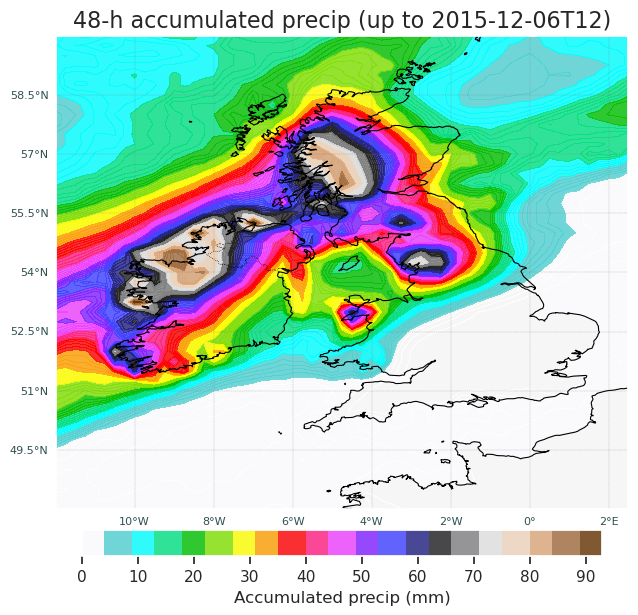

In [50]:
rolling_window = 48
min_periods = 48
event_end_date = '2015-12-06T12'
ds = xr.open_dataset('/mnt/metdata/2025s1985/era5/hourly_surface/tp/reanalysis-era5-single-levels_2015_month12.nc')
da_pr_roll = preprocess_era5_rainfall(ds, 
                                      rolling_window=rolling_window, 
                                      min_periods=min_periods,
                                      event_end_date=event_end_date, 
                                      lead_dim='valid_time')

ireland_bbox = [-10.5, -5.5, 51.5, 55.5]
uk_bbox = [-12.0, 2.5, 48.0, 60.0]
fig = formatted_uk_and_ireland_plot(da_pr_roll,
                                    bbox=ireland_bbox,
                                    cmap=get_metpy_colourmap('precipitation'))
out_file = f'/mnt/metdata/2025s1985/output_plots/desmond_dec2015/era5_eva/ERA5_Desmond_{rolling_window}h_{event_end_date}_prcp.png'
plt.savefig(out_file, dpi=300, bbox_inches='tight', pad_inches=0)

## Read in the accumulated rainfall return levels

- Map the event to the relevant return period 
    - Input the event `xr.da` (i.e. accumulated rainfall corresponding to historical event)
    - Also input the `xr.da` containing return level values for the specified return periods (RPs), calculated separately by Kay 
    - Cycle through the RPs and return the first RP for which the return level threshold >= event rainfall  

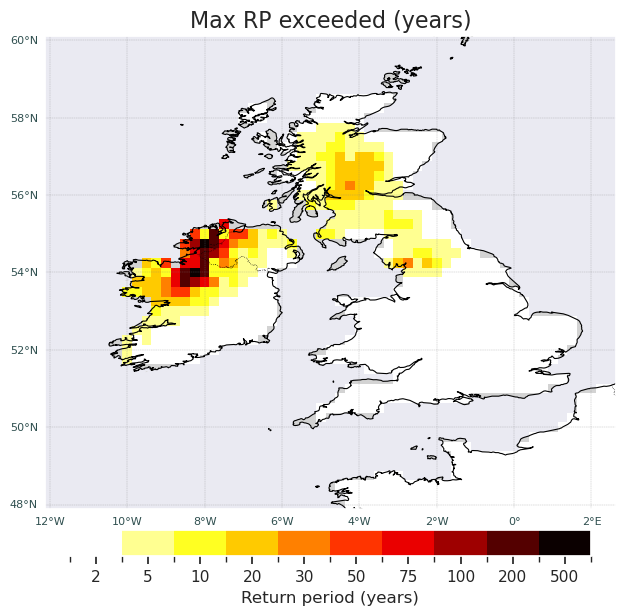

In [51]:
# define relevant parameters for mapping to return periods
rp_dim = 'rl'
event_da = da_pr_roll
acc_dim = None
fill_value = np.nan

# read in the return level data 
return_levels = xr.open_dataset(f'/mnt/metdata/2025s1985/era5_eva/{rolling_window}h/UKI_return_levels_{rolling_window}h_WY1980-2021.nc')
return_levels['return_level'] = return_levels['return_level'] * 1000.0  # convert from m to mm
return_levels = select_subset_by_bbox(return_levels, bbox=uk_bbox)[0]
thresholds_da = return_levels['return_level']

# map the event data to return periods
mapped_rp_da = map_event_to_return_period(event_da=da_pr_roll,
                                          thresholds_da=thresholds_da,
                                          rp_dim=rp_dim,
                                          acc_dim=acc_dim,
                                          acc_value=rolling_window,
                                          fill_value=fill_value,
                                          bbox=uk_bbox)

# plot the mapped return periods
fig = formatted_uk_and_ireland_plot(mapped_rp_da,
                                    bbox=uk_bbox,
                                    cmap='hot_r')
out_file = f'/mnt/metdata/2025s1985/output_plots/desmond_dec2015/era5_eva/ERA5_Desmond_{rolling_window}h_{event_end_date}_RPs.png'
plt.savefig(out_file, dpi=300, bbox_inches='tight', pad_inches=0)